<a href="https://colab.research.google.com/github/Pranoti15/My-DS-Projects/blob/my-branch/EDA_assignment4_insurance_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Upload Files to Google Drive via Google Colab**

In [1]:
from google.colab import files

uploaded = files.upload()  # Opens a file selection dialog

Saving insurance.csv to insurance.csv


After selecting a file, it will be uploaded to the Colab workspace.

Move the file to Google Drive:

In [2]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

Mounted at /content/drive


In [3]:

# Move uploaded file to Google Drive
!mv insurance.csv "/content/drive/My Drive/Data Science/Kaggle Datasets"

In [4]:
import pandas as pd

file_path = "/content/drive/My Drive/Data Science/Kaggle Datasets/insurance.csv"  # Change to your folder path
df = pd.read_csv(file_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#Automate Saving Process
#Once mounted, it works like a local drive, allowing you to load/save files automatically.
df.to_csv("/content/drive/My Drive/Data Science/Kaggle Datasets/processed_insurance.csv", index=False)

In [5]:
# Display basic information about the dataset
df_info = df.info()
df_head = df.head()
df_shape = df.shape
df_summary = df.describe(include="all")

df_info, df_head, df_shape, df_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


(None,
    age     sex     bmi  children smoker     region      charges
 0   19  female  27.900         0    yes  southwest  16884.92400
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520,
 (1338, 7),
                 age   sex          bmi     children smoker     region  \
 count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
 unique          NaN     2          NaN          NaN      2          4   
 top             NaN  male          NaN          NaN     no  southeast   
 freq            NaN   676          NaN          NaN   1064        364   
 mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
 std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
 min       18.000000   NaN    15.960000     0.000000    NaN        NaN  

**Step 1: Setup and Data Preparation**

**Dataset Overview:**

Total Entries: 1338

Total Columns: 7

**Column Types:**

Numerical: age, bmi, children, charges

Categorical: sex, smoker, region

**Summary Statistics:**

Age Range: 18 to 64 (Mean: 39.2)

BMI Range: 15.96 to 53.13 (Mean: 30.66)

Children Count: 0 to 5 (Mean: 1.09)

Insurance Charges: ₹1,121 to ₹63,770 (Mean: ₹13,270)

**Missing Values:**

There are no missing values in the dataset.

Next, let's visualize feature distributions and analyze relationships between variables.

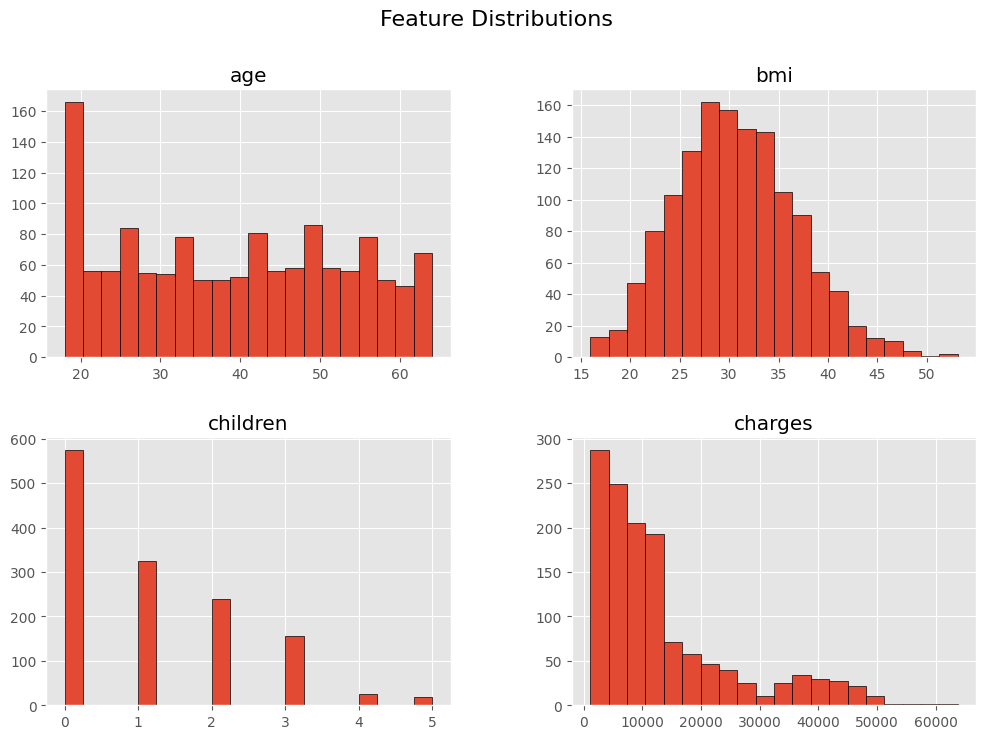

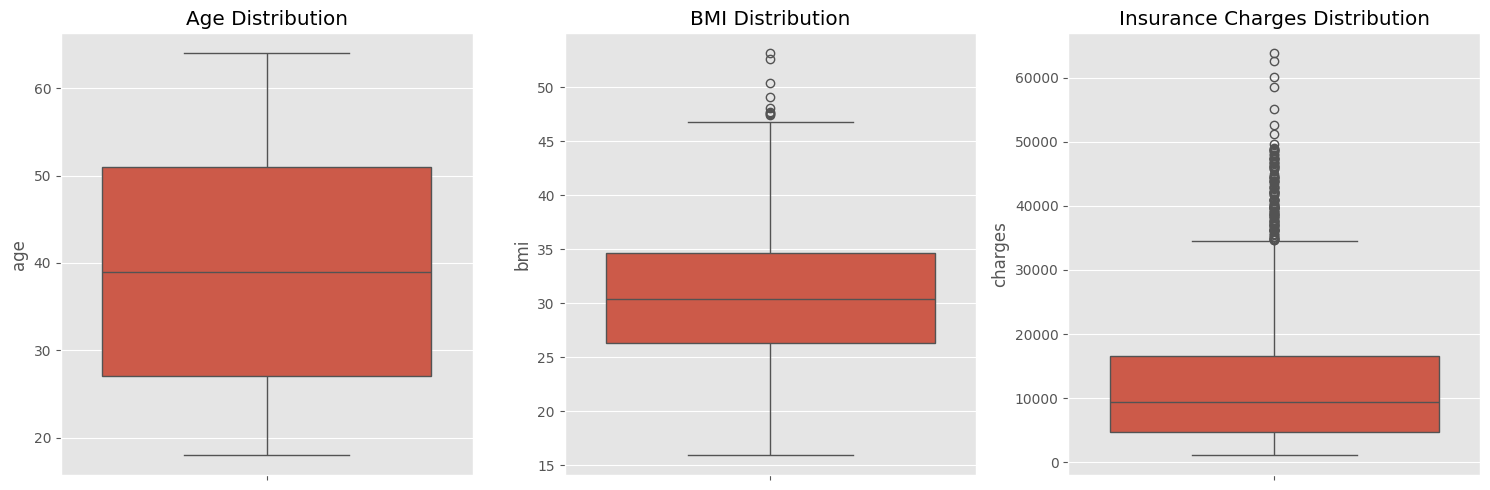

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
plt.style.use('ggplot')

# Histograms for numerical features
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

# Boxplots for numerical features to check for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["age"], ax=axes[0])
axes[0].set_title("Age Distribution")

sns.boxplot(y=df["bmi"], ax=axes[1])
axes[1].set_title("BMI Distribution")

sns.boxplot(y=df["charges"], ax=axes[2])
axes[2].set_title("Insurance Charges Distribution")

plt.tight_layout()
plt.show()

**Step 2: Exploratory Data Analysis**

**Feature Distributions:**

Age: The distribution is fairly uniform across different age groups.

BMI: A right-skewed distribution with some extreme values indicating potential outliers.

Children: Most individuals have 0-2 children, with fewer having 3-5.

Charges: Highly right-skewed, suggesting that a few individuals have very high insurance costs.

**Outliers:**

The BMI and charges columns contain outliers, which could affect predictive modeling.

Next, I will analyze relationships between numerical variables.

In [ ]:
# Convert categorical variables to numerical
#df_numeric = df.copy()
#df_numeric["sex"] = df_numeric["sex"].map({"male": 0, "female": 1})
#df_numeric["smoker"] = df_numeric["smoker"].map({"no": 0, "yes": 1})
#df_numeric = pd.get_dummies(df_numeric, columns=["region"], drop_first=True)

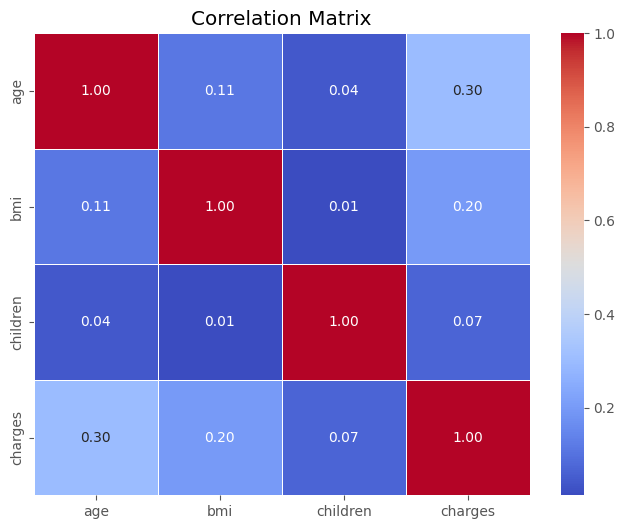

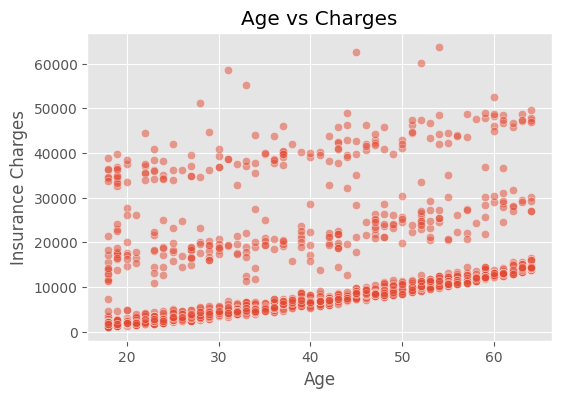

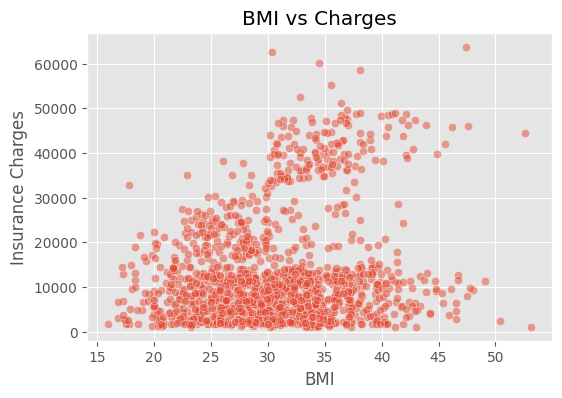

In [ ]:
# Correlation matrix for numerical features
corr_matrix = df.corr(numeric_only=True)

# Heatmap to visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# Scatter plot for Age vs Charges
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["age"], y=df["charges"], alpha=0.5)
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

# Scatter plot for BMI vs Charges
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["bmi"], y=df["charges"], alpha=0.5)
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

**Key Observations from Correlation and Scatter Plots:**

Strong Correlation Between Charges and BMI: Higher BMI tends to correspond with higher insurance charges.

Weak Correlation Between Age and Charges: Insurance charges increase slightly with age, but the relationship isn't strong.

Charges Have a Right-Skewed Distribution: Some individuals have significantly higher insurance costs.

Next, I'll analyze categorical variables.

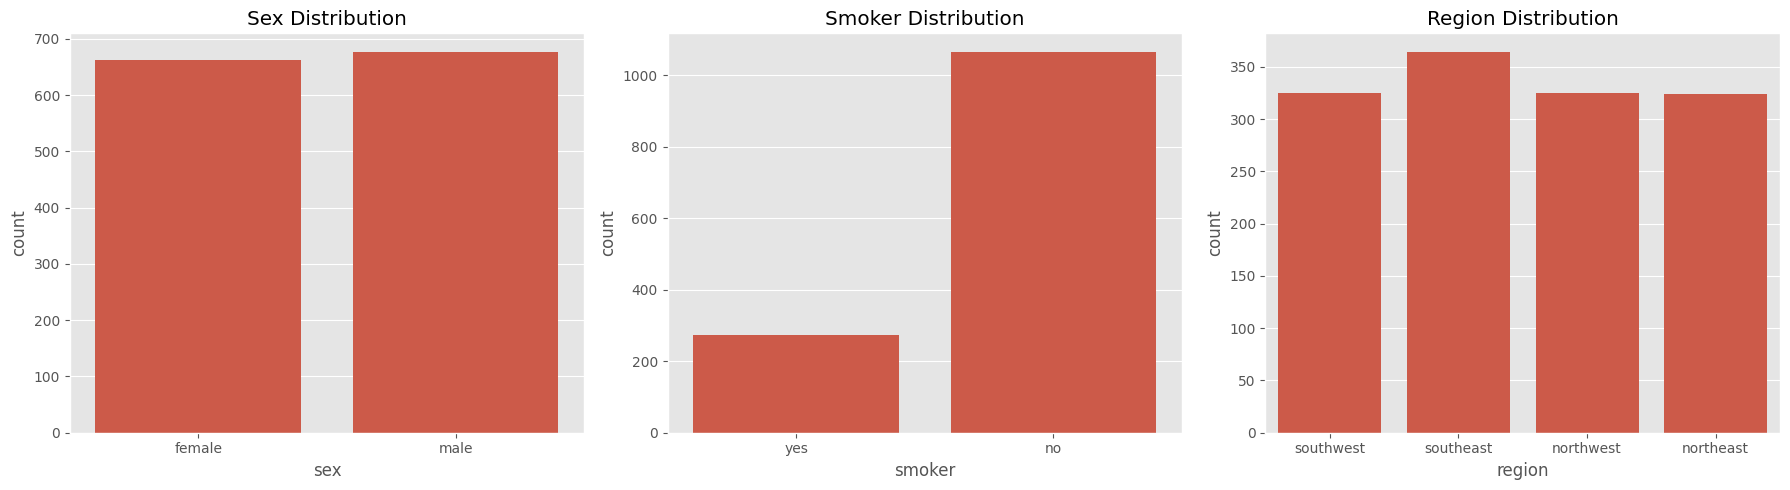

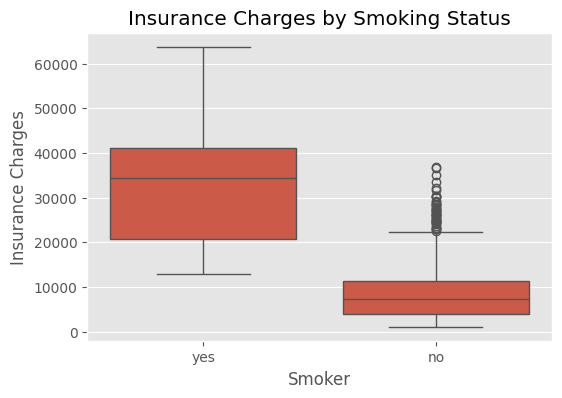

In [ ]:
# Bar plots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sex distribution
sns.countplot(x=df["sex"], ax=axes[0])
axes[0].set_title("Sex Distribution")

# Smoker distribution
sns.countplot(x=df["smoker"], ax=axes[1])
axes[1].set_title("Smoker Distribution")

# Region distribution
sns.countplot(x=df["region"], ax=axes[2])
axes[2].set_title("Region Distribution")

plt.tight_layout()
plt.show()

# Box plot of charges by smoker status
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["smoker"], y=df["charges"])
plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")
plt.show()

**Insights from Categorical Data Analysis:**

Sex Distribution: Nearly equal representation of males and females.

Smoker Status: Majority (around 80%) are non-smokers.

Region Distribution: The southeast region has the most individuals.

Smokers Pay Higher Insurance Charges: The box plot clearly shows that smokers tend to have significantly higher insurance costs compared to non-smokers.

Next, I will handle missing values, encode categorical features, and standardize numerical variables. ​

In [11]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


The dataset does not have any missing values, so we can proceed with encoding categorical features and standardizing numerical features.

**Next steps:**
**Encode categorical features:**

**sex**: We'll encode "female" as 0 and "male" as 1.

**smoker**: We'll encode "no" as 0 and "yes" as 1.

**region**: We'll convert the regions into separate binary columns (one-hot encoding).

**Standardize numerical features**: We'll standardize the numerical columns (age, bmi, children, and charges) using standard scaling.

In [12]:
# Check for missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


If there are missing values, you can decide whether to fill them (using the mean, median, or mode) or drop the rows/columns:

**Option 1:** Fill missing values with the mean (for numerical columns)

df.fillna(df.mean(), inplace=True)

**Option 2:** Drop rows with missing values

df.dropna(inplace=True)

**Encode categorical features**

Identify categorical columns (they usually have object types) and encode them using one-hot encoding or label encoding. Here's how you can do it:

**One-Hot Encoding:**

In [14]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)  # drop_first avoids multicollinearity

**Label Encoding (if required)**:
If you prefer label encoding, use LabelEncoder from sklearn:

from sklearn.preprocessing import LabelEncoder

**#Create a LabelEncoder object**

le = LabelEncoder()

**# Encode each categorical column**

df['Category_Column'] = le.fit_transform(df['Category_Column'])

**Standardize numerical features**

Identify the numerical columns and standardize them using StandardScaler from sklearn:

In [16]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Create a StandardScaler object
scaler = StandardScaler()

# Standardize the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])



**Step 5: Save the processed data (optional)**

After preprocessing, you can save the processed dataset to a new CSV file:

In [18]:
# Save the processed dataset
df.to_csv('/content/drive/MyDrive/Data Science/Kaggle Datasets/Processed datasets/processed_insurance.csv', index=False)

# The End